<a href="https://colab.research.google.com/github/faqihrfaldy3/faqihbae.github.io/blob/main/lstm%26prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prophet --quiet
!pip install datasets --quiet
!pip install scikit-learn --quiet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Prophet
from prophet import Prophet

# LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


## 1. Data Loading and Initial Exploration

First, we'll load the dataset from Hugging Face and convert it into a Pandas DataFrame. We'll then inspect the first few rows to understand its structure.

In [2]:
from datasets import load_dataset

# Load the dataset from Hugging Face
dataset = load_dataset('theonegareth/antam_historical_gold_prices')

# Convert the 'train' split to a pandas DataFrame
df = pd.DataFrame(dataset['train'])

# Display the first 5 rows of the DataFrame
display(df.head())

# Display basic information about the DataFrame
display(df.info())

README.md:   0%|          | 0.00/4.77k [00:00<?, ?B/s]

Antam_historical_gold_prices.csv:   0%|          | 0.00/207k [00:00<?, ?B/s]

Antam_historical_gold_prices_raw.csv:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9731 [00:00<?, ? examples/s]

,Time (ms),Gold Price,Date
0,1262596020000,408000,2010-01-04 09:07:00
1,1262683680000,410000,2010-01-05 09:28:00
2,1262761260000,410000,2010-01-06 07:01:00
3,1262857500000,412000,2010-01-07 09:45:00
4,1262943420000,410000,2010-01-08 09:37:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9731 entries, 0 to 9730
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Time (ms)   9731 non-null   int64 
 1   Gold Price  9731 non-null   int64 
 2   Date        4893 non-null   object
dtypes: int64(2), object(1)
memory usage: 228.2+ KB


None

## 2. Data Preprocessing

In this step, we will prepare the data for modeling. This involves:
- Converting the 'Date' column to datetime objects.
- Renaming columns for clarity (e.g., 'Date' and 'Price').
- Handling missing values.
- Checking for and removing duplicate entries based on the date.

In [3]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Rename columns for clarity
df = df.rename(columns={'Date': 'Date', 'Gold Price': 'Price'})

# Drop the original 'Time (ms)' column as 'Date' is sufficient
df = df.drop(columns=['Time (ms)'])

# Handle missing values in 'Date' by dropping rows where 'Date' is NaT
df.dropna(subset=['Date'], inplace=True)

# Sort the DataFrame by 'Date'
df = df.sort_values(by='Date').reset_index(drop=True)

# Check for and remove duplicate dates, keeping the last entry in case of multiple prices for the same date
df = df.drop_duplicates(subset=['Date'], keep='last')

# Display the first few rows of the preprocessed DataFrame and its info
display(df.head())
display(df.info())

# Display descriptive statistics for 'Price'
display(df['Price'].describe())

,Price,Date
0,408000,2010-01-04 09:07:00
1,410000,2010-01-05 09:28:00
2,410000,2010-01-06 07:01:00
3,412000,2010-01-07 09:45:00
4,410000,2010-01-08 09:37:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4893 entries, 0 to 4892
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   4893 non-null   int64         
 1   Date    4893 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 76.6 KB


None

,Price
count,4.893000e+03
mean,8.520455e+05
std,3.988312e+05
min,3.940000e+05
25%,5.720000e+05
50%,6.690000e+05
75%,9.990000e+05
max,2.487000e+06


## 3. Data Visualization

Before proceeding with model building, it's essential to visualize the gold price data to identify trends, seasonality, and any significant patterns or anomalies. This step helps in understanding the underlying structure of the time series.

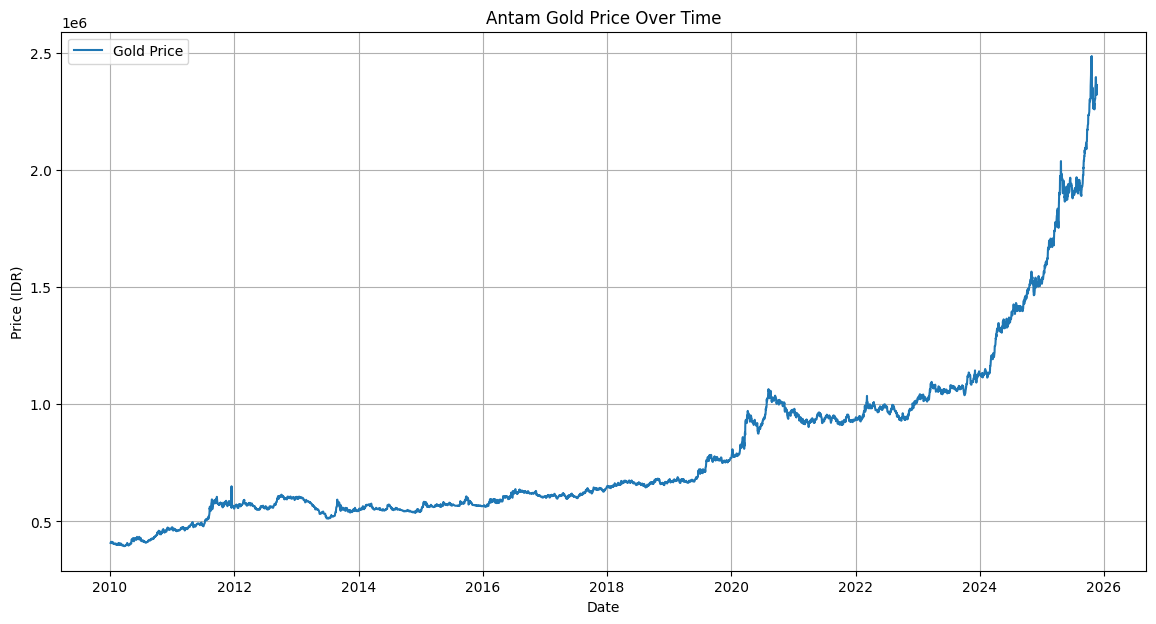

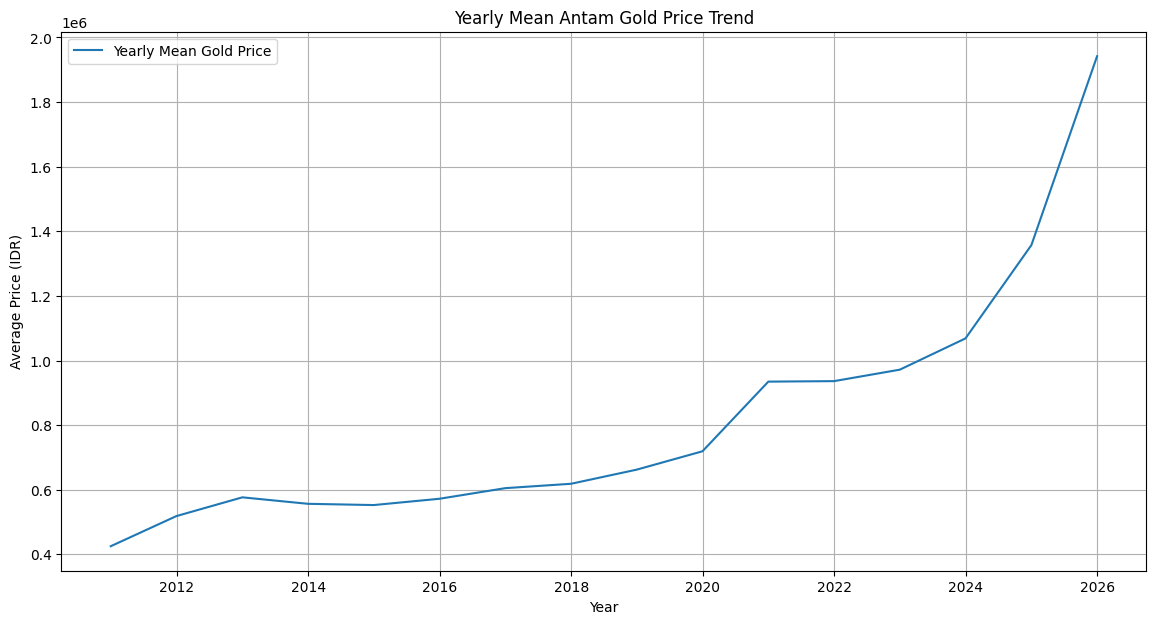

In [4]:
# Set the Date column as the index for time series plotting
df_plot = df.set_index('Date')

# Plot the gold prices over time
plt.figure(figsize=(14, 7))
plt.plot(df_plot['Price'], label='Gold Price')
plt.title('Antam Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (IDR)')
plt.grid(True)
plt.legend()
plt.show()

# Plotting yearly trends if the data spans multiple years
plt.figure(figsize=(14, 7))
plt.plot(df_plot['Price'].resample('Y').mean(), label='Yearly Mean Gold Price')
plt.title('Yearly Mean Antam Gold Price Trend')
plt.xlabel('Year')
plt.ylabel('Average Price (IDR)')
plt.grid(True)
plt.legend()
plt.show()

## 4. Data Preparation for Modeling

For time series forecasting, it's crucial to split the data into training and testing sets. Additionally, both Prophet and LSTM models have specific input requirements for their data format.

### 4.1 Data Preparation for Prophet

Prophet requires the input DataFrame to have two columns: `ds` (datestamp) and `y` (the metric to be forecasted). We will rename our `Date` and `Price` columns accordingly and then split the data.

In [5]:
# Prepare data for Prophet: rename columns to 'ds' and 'y'
prophet_df = df.rename(columns={'Date': 'ds', 'Price': 'y'})

# Define the split point for training and testing (e.g., last 365 days for testing)
train_size = len(prophet_df) - 365

prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

print(f"Prophet Training data shape: {prophet_train.shape}")
print(f"Prophet Testing data shape: {prophet_test.shape}")

display(prophet_train.head())
display(prophet_test.head())

Prophet Training data shape: (4528, 2)
Prophet Testing data shape: (365, 2)


,y,ds
0,408000,2010-01-04 09:07:00
1,410000,2010-01-05 09:28:00
2,410000,2010-01-06 07:01:00
3,412000,2010-01-07 09:45:00
4,410000,2010-01-08 09:37:00


,y,ds
4528,1517000,2024-12-15 05:47:46
4529,1517000,2024-12-16 08:15:54
4530,1520000,2024-12-17 08:10:36
4531,1520000,2024-12-18 08:06:47
4532,1505000,2024-12-19 08:33:07


### 4.2 Data Preparation for LSTM

LSTM models require numerical input and often perform better with scaled data. We will normalize the 'Price' column and then create sequences for training and testing. We will also define a function to create time series sequences for the LSTM model.

In [6]:
# Normalize the 'Price' data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Price'].values.reshape(-1, 1))

# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Define sequence length
seq_length = 60 # Using 60 days to predict the next day's price

# Split scaled data into training and testing sets for LSTM
lstm_train_data = scaled_data[:train_size]
lstm_test_data = scaled_data[train_size - seq_length:] # Need to include previous `seq_length` days for testing

# Create sequences for LSTM training and testing
X_train, y_train = create_sequences(lstm_train_data, seq_length)
X_test, y_test = create_sequences(lstm_test_data, seq_length)

print(f"LSTM X_train shape: {X_train.shape}")
print(f"LSTM y_train shape: {y_train.shape}")
print(f"LSTM X_test shape: {X_test.shape}")
print(f"LSTM y_test shape: {y_test.shape}")

# Display the first few elements of the created sequences to verify
print("First 5 elements of X_train (reshaped for display):")
print(X_train[:5].reshape(5, seq_length))
print("First 5 elements of y_train:")
print(y_train[:5].flatten())

LSTM X_train shape: (4468, 60, 1)
LSTM y_train shape: (4468, 1)
LSTM X_test shape: (365, 60, 1)
LSTM y_test shape: (365, 1)
First 5 elements of X_train (reshaped for display):
[[0.00668896 0.00764453 0.00764453 0.0086001  0.00764453 0.00907788
  0.00764453 0.00716675 0.00764453 0.00668896 0.0057334  0.00764453
  0.00764453 0.00668896 0.00477783 0.00477783 0.00477783 0.00477783
  0.00430005 0.00430005 0.00430005 0.00525561 0.0057334  0.00477783
  0.00334448 0.0028667  0.00334448 0.00382226 0.00334448 0.00430005
  0.00382226 0.00430005 0.0057334  0.00334448 0.00334448 0.00668896
  0.00382226 0.00334448 0.0028667  0.00477783 0.00334448 0.00525561
  0.0057334  0.00430005 0.00477783 0.0028667  0.00238892 0.00191113
  0.00191113 0.00143335 0.0028667  0.00191113 0.00095557 0.00047778
  0.00047778 0.         0.00047778 0.00095557 0.00095557 0.00047778]
 [0.00764453 0.00764453 0.0086001  0.00764453 0.00907788 0.00764453
  0.00716675 0.00764453 0.00668896 0.0057334  0.00764453 0.00764453
  0.006

## 5. Model Building and Training

We will now build and train both the Prophet and LSTM models using their respective prepared datasets.

### 5.1 Prophet Model

We will initialize a Prophet model, fit it to the training data, and then make future predictions.

,ds,yhat,yhat_lower,yhat_upper
0,2010-01-04 09:07:00,387132.312653,344962.259592,431621.550993
1,2010-01-05 09:28:00,387591.808618,344608.489812,431048.785979
2,2010-01-06 07:01:00,381069.700866,335549.275877,424932.137258
3,2010-01-07 09:45:00,388038.379610,342524.136180,432560.543704
4,2010-01-08 09:37:00,388434.985950,346446.899598,434273.944824


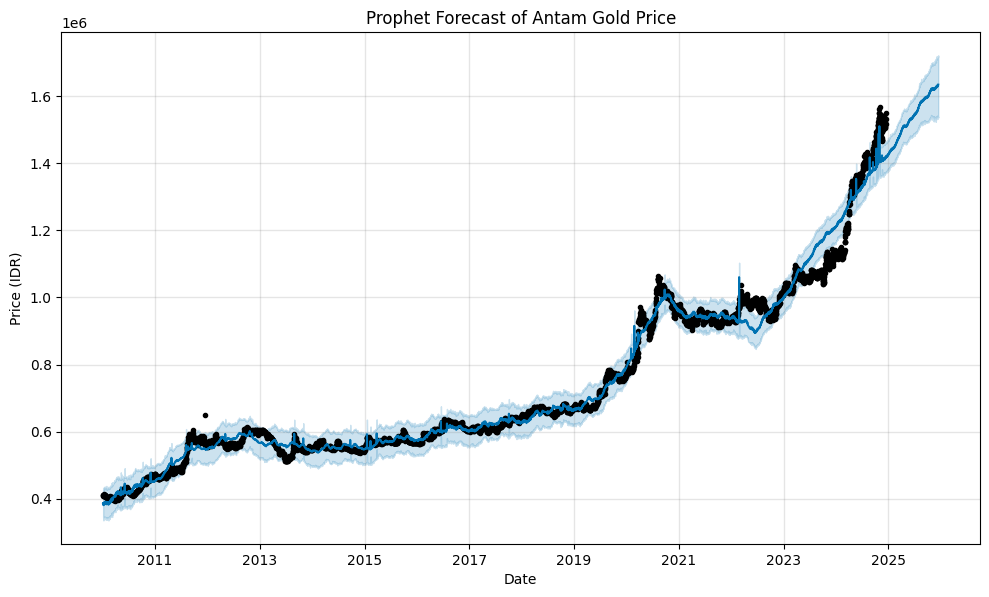

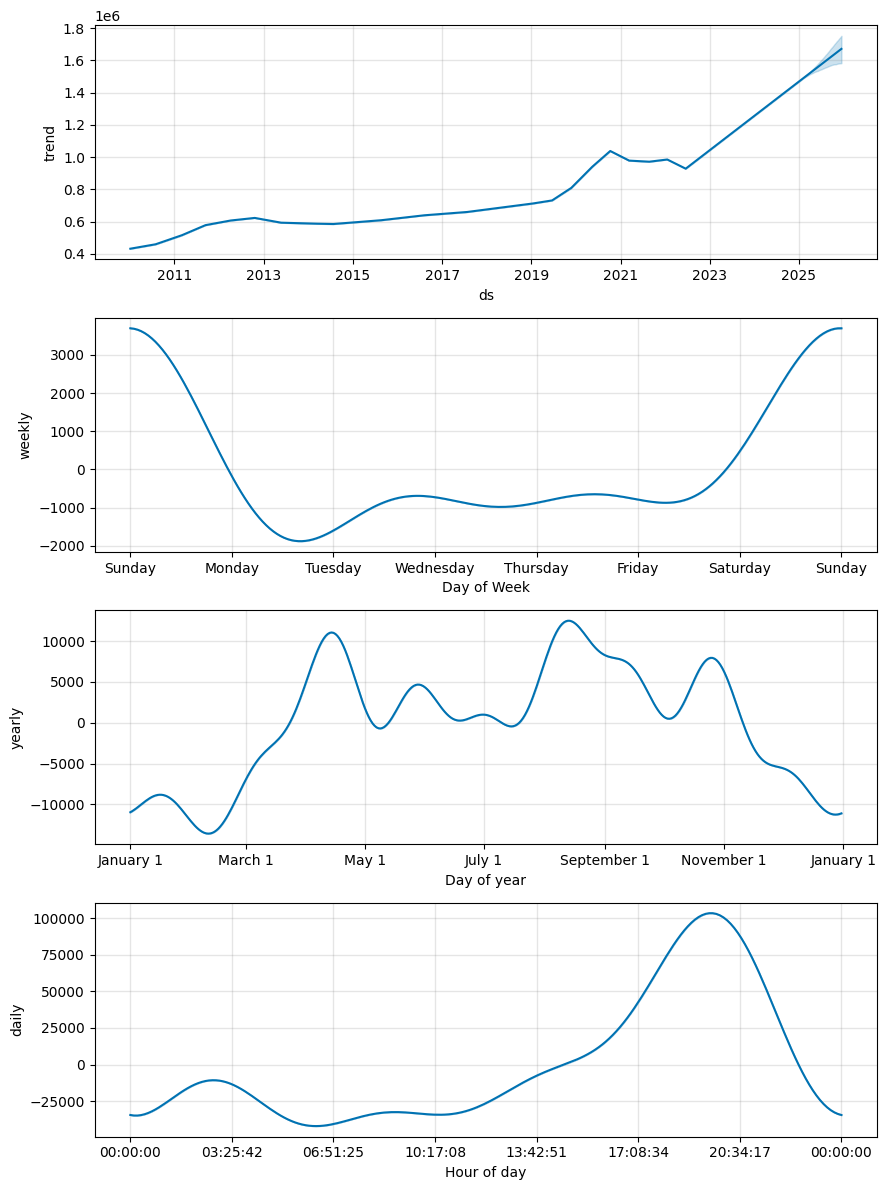

In [7]:
# Initialize and train Prophet model
m_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
m_prophet.fit(prophet_train)

# Create a DataFrame for future predictions
future = m_prophet.make_future_dataframe(periods=len(prophet_test), freq='D')

# Make predictions
prophet_forecast = m_prophet.predict(future)

# Display the first few rows of the forecast
display(prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Plot the Prophet forecast
fig1 = m_prophet.plot(prophet_forecast)
plt.title('Prophet Forecast of Antam Gold Price')
plt.xlabel('Date')
plt.ylabel('Price (IDR)')
plt.show()

# Plot the Prophet components
fig2 = m_prophet.plot_components(prophet_forecast)
plt.show()

### 5.2 LSTM Model

We will now define, compile, and train the LSTM model. The model will consist of an input LSTM layer, followed by dropout layers to prevent overfitting, and a dense output layer.

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0011 - val_loss: 9.2536e-05
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 2.0793e-04 - val_loss: 2.6664e-04
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 1.7779e-04 - val_loss: 1.7669e-04
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 1.5678e-04 - val_loss: 5.5378e-05
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 1.4268e-04 - val_loss: 5.2668e-04
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 1.3723e-04 - val_loss: 6.3573e-05
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 1.2110e-04 - val_loss: 1.4396e-04
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 1.2445e-04 - val_loss: 2.4572e-04
Epoch 9/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 1.0587e-04 - val_loss: 4.4770e-04
Epoch 10/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 9.2689e-05 - val_loss: 1.3343e-04
Epoch 11/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/st

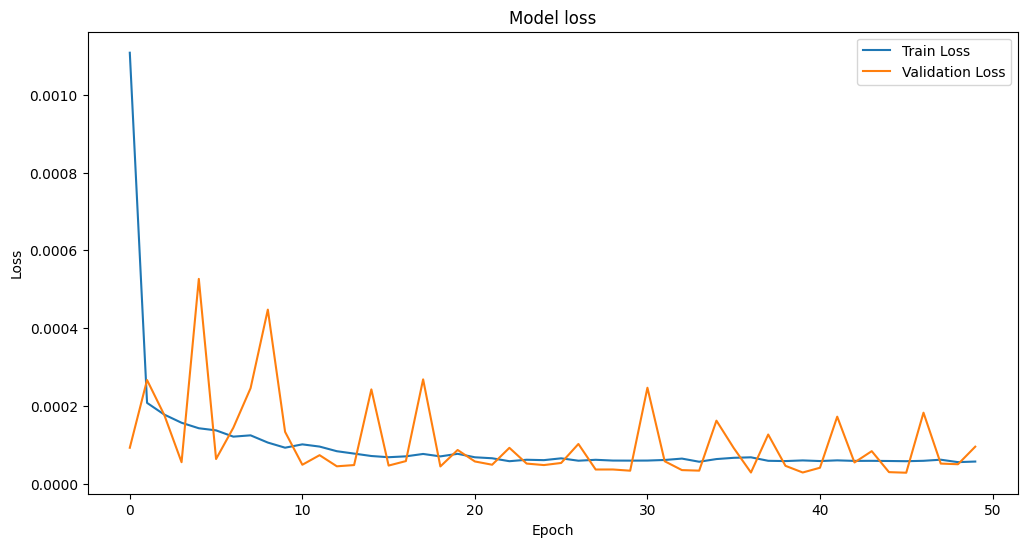

In [8]:
# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Implement Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    epochs=50, # You might want to increase this for better performance
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM Model Training Complete.")

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

## 6. Model Evaluation

Now that both models are trained, we will evaluate their performance on the test set using various metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and Mean Absolute Percentage Error (MAPE). We will also visualize the predictions against the actual values.

### 6.1 Prophet Model Evaluation

Prophet MAE: 373807.24
Prophet MSE: 171258912879.46
Prophet RMSE: 413834.40
Prophet MAPE: 18.88%


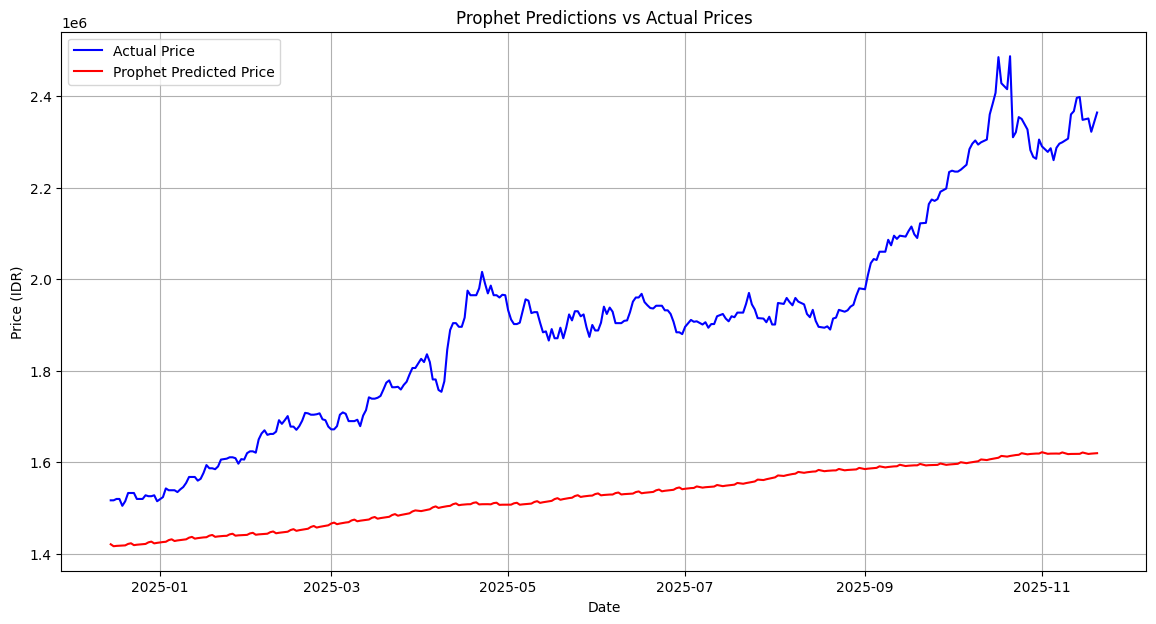

In [11]:
# --- Fix for Prophet Evaluation ---
# Define the actual test dates (normalized)
test_dates_normalized = prophet_test['ds'].dt.normalize().unique() # Use unique to ensure one entry per day

# Filter prophet_forecast to get predictions for these specific dates
# First, ensure prophet_forecast['ds'] is also normalized for matching
prophet_forecast_copy = prophet_forecast.copy() # Avoid modifying original prophet_forecast
prophet_forecast_copy['ds'] = prophet_forecast_copy['ds'].dt.normalize()

# Filter predictions for the dates present in the test set
prophet_predictions_for_test_dates = prophet_forecast_copy[prophet_forecast_copy['ds'].isin(test_dates_normalized)]

# Create DataFrames for merging, ensuring unique dates are used as index
actual_df = prophet_test.copy()
actual_df['ds'] = actual_df['ds'].dt.normalize()
actual_df = actual_df.drop_duplicates(subset=['ds']).set_index('ds')

predicted_df = prophet_predictions_for_test_dates.copy()
# Drop duplicates in case prophet_forecast_copy had multiple entries for a normalized date (less likely but safe)
predicted_df = predicted_df.drop_duplicates(subset=['ds']).set_index('ds')

# Now, perform an inner join on the index (normalized date) to get only common dates
prophet_results_merged = actual_df.join(predicted_df[['yhat']], how='inner')

if prophet_results_merged.empty:
    print("Warning: Prophet results DataFrame is empty after merging. Cannot calculate metrics or plot.")
else:
    # Calculate evaluation metrics for Prophet
    mae_prophet = mean_absolute_error(prophet_results_merged['y'], prophet_results_merged['yhat'])
    mse_prophet = mean_squared_error(prophet_results_merged['y'], prophet_results_merged['yhat'])
    rmse_prophet = np.sqrt(mse_prophet)
    mape_prophet = np.mean(np.abs((prophet_results_merged['y'] - prophet_results_merged['yhat']) / prophet_results_merged['y'])) * 100

    print(f"Prophet MAE: {mae_prophet:.2f}")
    print(f"Prophet MSE: {mse_prophet:.2f}")
    print(f"Prophet RMSE: {rmse_prophet:.2f}")
    print(f"Prophet MAPE: {mape_prophet:.2f}%")

    # Plot Prophet predictions vs actual values
    plt.figure(figsize=(14, 7))
    plt.plot(prophet_results_merged.index, prophet_results_merged['y'], label='Actual Price', color='blue')
    plt.plot(prophet_results_merged.index, prophet_results_merged['yhat'], label='Prophet Predicted Price', color='red')
    plt.title('Prophet Predictions vs Actual Prices')
    plt.xlabel('Date')
    plt.ylabel('Price (IDR)')
    plt.legend()
    plt.grid(True)
    plt.show()

### 6.2 LSTM Model Evaluation

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
LSTM MAE: 33114.26
LSTM MSE: 1822512328.66
LSTM RMSE: 42690.89
LSTM MAPE: 1.65%


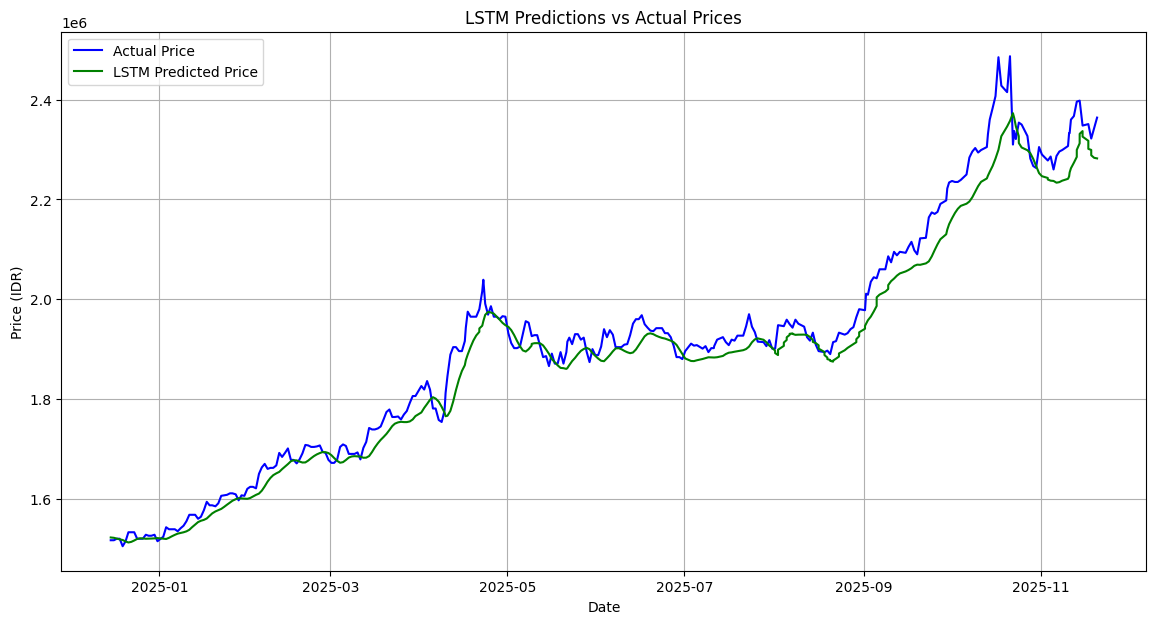

In [12]:
# Make predictions on the test set for LSTM
lstm_predictions_scaled = lstm_model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)
actual_prices_lstm = scaler.inverse_transform(y_test)

# Align dates for plotting and evaluation
# y_test contains values corresponding to dates from original df starting at index `train_size`
# and extending for `len(y_test)` entries.
# This slicing ensures forecast_dates has exactly the same length as y_test
forecast_dates = df['Date'].iloc[train_size : train_size + len(y_test)].values

# Create a DataFrame for LSTM results
lstm_results = pd.DataFrame({
    'Date': forecast_dates,
    'Actual': actual_prices_lstm.flatten(),
    'Predicted': lstm_predictions.flatten()
}).set_index('Date')

# Calculate evaluation metrics for LSTM
mae_lstm = mean_absolute_error(lstm_results['Actual'], lstm_results['Predicted'])
mse_lstm = mean_squared_error(lstm_results['Actual'], lstm_results['Predicted'])
rmse_lstm = np.sqrt(mse_lstm)
mape_lstm = np.mean(np.abs((lstm_results['Actual'] - lstm_results['Predicted']) / lstm_results['Actual'])) * 100

print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"LSTM MSE: {mse_lstm:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"LSTM MAPE: {mape_lstm:.2f}%")

# Plot LSTM predictions vs actual values
plt.figure(figsize=(14, 7))
plt.plot(lstm_results['Actual'], label='Actual Price', color='blue')
plt.plot(lstm_results['Predicted'], label='LSTM Predicted Price', color='green')
plt.title('LSTM Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Price (IDR)')
plt.legend()
plt.grid(True)
plt.show()

## 7. Future Forecasting

Now, let's use the trained models to forecast gold prices for the next 6 months.

### 7.1 Prophet Future Forecasting

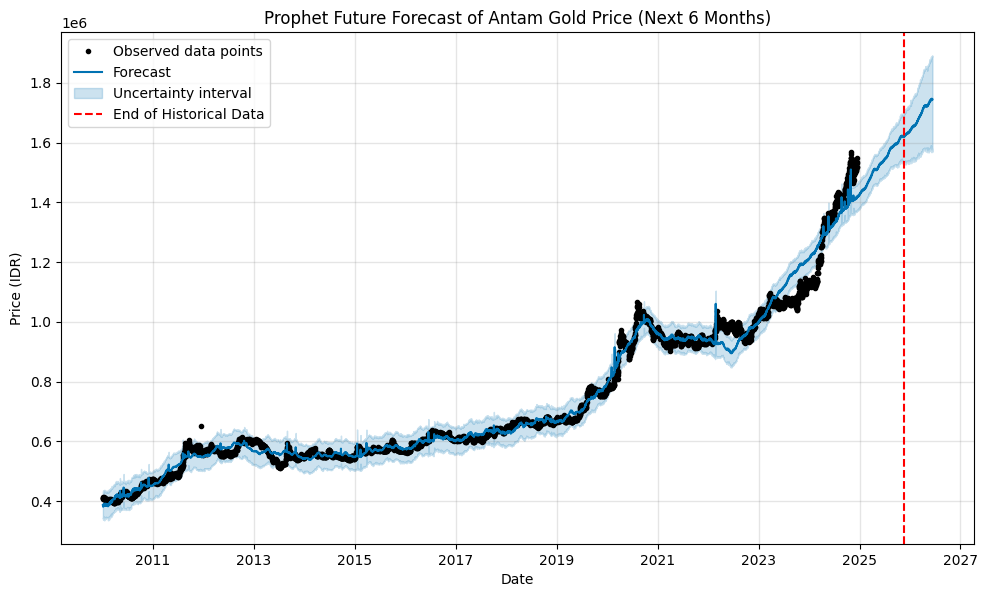

,ds,yhat,yhat_lower,yhat_upper
5068,2026-06-08 08:31:22,1.742466e+06,1.575246e+06,1.885061e+06
5069,2026-06-09 08:31:22,1.743194e+06,1.580693e+06,1.891476e+06
5070,2026-06-10 08:31:22,1.743602e+06,1.571319e+06,1.890182e+06
5071,2026-06-11 08:31:22,1.744119e+06,1.572658e+06,1.888718e+06
5072,2026-06-12 08:31:22,1.744279e+06,1.569232e+06,1.890169e+06


In [13]:
# Extend the future DataFrame for the next 6 months (approx 180 days)
future_extended = m_prophet.make_future_dataframe(periods=len(prophet_test) + 180, freq='D')

# Make predictions for the extended future
prophet_future_forecast = m_prophet.predict(future_extended)

# Filter to show only the future predictions (beyond the original test set)
# Get the last date from the original data
last_original_date = df['Date'].max()

# Filter prophet_future_forecast to only include dates after the last original date
future_predictions_prophet = prophet_future_forecast[prophet_future_forecast['ds'] > last_original_date]

# Plot the future Prophet forecast
fig_prophet_future = m_prophet.plot(prophet_future_forecast)
plt.title('Prophet Future Forecast of Antam Gold Price (Next 6 Months)')
plt.xlabel('Date')
plt.ylabel('Price (IDR)')

# Highlight the forecasted period
plt.axvline(last_original_date, color='r', linestyle='--', label='End of Historical Data')
plt.legend()
plt.show()

display(future_predictions_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

### 7.2 LSTM Future Forecasting

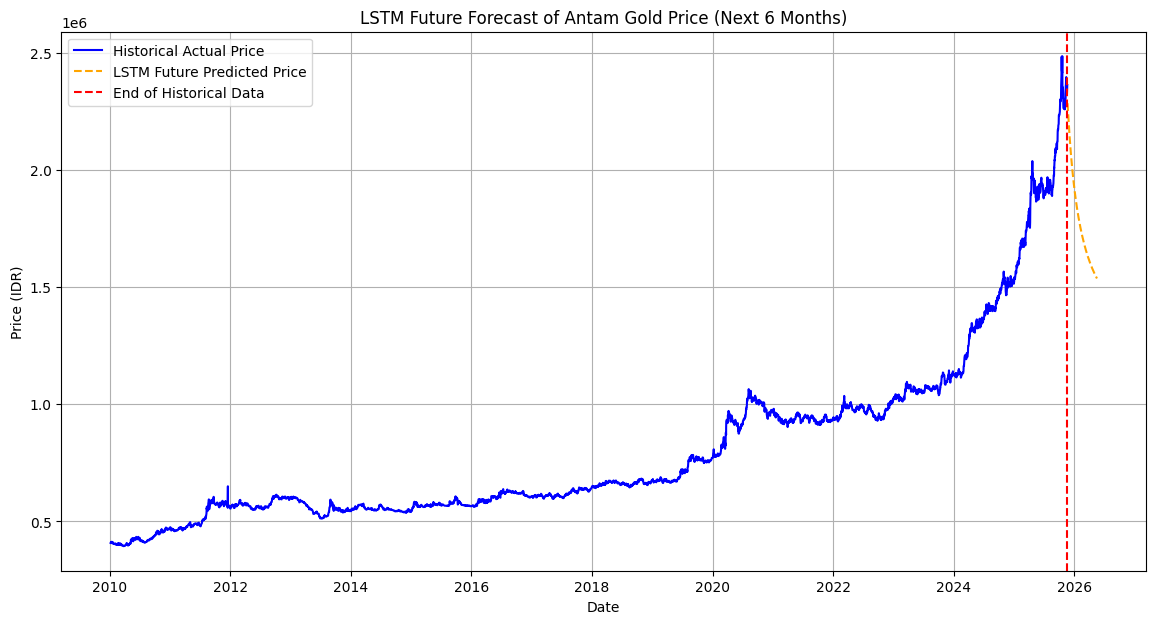

,Predicted
Date,
2025-11-21 08:50:35,2286087.75
2025-11-22 08:50:35,2281003.75
2025-11-23 08:50:35,2271898.25
2025-11-24 08:50:35,2260733.75
2025-11-25 08:50:35,2248644.75


,Predicted
Date,
2026-05-15 08:50:35,1543093.125
2026-05-16 08:50:35,1541723.250
2026-05-17 08:50:35,1540363.875
2026-05-18 08:50:35,1539015.875
2026-05-19 08:50:35,1537678.000


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [14]:
# Prepare the last 'seq_length' days from the entire dataset for initial LSTM prediction
last_sequence = scaled_data[-seq_length:]

# Create a list to store future predictions
lstm_future_predictions_scaled = []

# Number of future days to predict (6 months * approx 30 days/month)
num_future_days = 180

current_sequence = last_sequence.reshape(1, seq_length, 1)

for _ in range(num_future_days):
    # Predict the next day's price
    next_prediction_scaled = lstm_model.predict(current_sequence, verbose=0)[0]
    lstm_future_predictions_scaled.append(next_prediction_scaled)

    # Update the sequence: remove the first element and add the new prediction
    current_sequence = np.append(current_sequence[:, 1:, :], [[next_prediction_scaled]], axis=1)

# Inverse transform the future predictions to original scale
lstm_future_predictions = scaler.inverse_transform(np.array(lstm_future_predictions_scaled).reshape(-1, 1))

# Generate future dates
last_date_in_df = df['Date'].max()
future_dates = pd.date_range(start=last_date_in_df + pd.Timedelta(days=1), periods=num_future_days, freq='D')

# Create a DataFrame for LSTM future results
lstm_future_results = pd.DataFrame({
    'Date': future_dates,
    'Predicted': lstm_future_predictions.flatten()
}).set_index('Date')

# Plot LSTM future predictions
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Price'], label='Historical Actual Price', color='blue')
plt.plot(future_dates, lstm_future_results['Predicted'], label='LSTM Future Predicted Price', color='orange', linestyle='--')
plt.title('LSTM Future Forecast of Antam Gold Price (Next 6 Months)')
plt.xlabel('Date')
plt.ylabel('Price (IDR)')
plt.axvline(last_date_in_df, color='r', linestyle='--', label='End of Historical Data')
plt.legend()
plt.grid(True)
plt.show()

display(lstm_future_results.head())
display(lstm_future_results.tail())